<a href="https://colab.research.google.com/github/enriquefroes/futebol-dinheiro-e-desempenho/blob/main/notebooks/02_pontos_por_folha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from google.colab import drive
    drive.mount('/content/drive')
    BASE = '/content/drive/MyDrive/analise_futebol'
except ImportError:
    BASE = './analise_futebol'

DADOS, GRAF, TAB = (os.path.join(BASE, p) for p in ['dados', 'graficos', 'tabelas'])
for p in (DADOS, GRAF, TAB):
    os.makedirs(p, exist_ok=True)

ARQUIVO = os.path.join(DADOS, 'clubes_2026.csv')
if not os.path.exists(ARQUIVO):
    raise FileNotFoundError('Rode primeiro o notebook 00_dados.ipynb para criar o CSV no Drive.')
df = pd.read_csv(ARQUIVO)

MESES_DECORRIDOS = 9
df['pontos_por_jogo'] = df['pontos'] / df['jogos']
df['gasto_transferencias'] = df['gasto_janela1'].fillna(0) + df['gasto_janela2'].fillna(0)
df['folha_anual'] = df['folha_mensal'] * 13
df['folha_ate_agora'] = df['folha_mensal'] * MESES_DECORRIDOS

def rotular(ax, dados, x, y, ajustes=None):
    """Escreve o nome do clube ao lado de cada ponto; 'ajustes' desloca rótulos sobrepostos."""
    ajustes = ajustes or {}
    for _, r in dados.iterrows():
        ax.annotate(r['time'], (r[x], r[y]), xytext=ajustes.get(r['time'], (6, 4)),
                    textcoords='offset points', fontsize=9)

def salvar(nome):
    plt.tight_layout()
    plt.savefig(os.path.join(GRAF, nome), dpi=150)
    plt.show()
    print('Salvo em', os.path.join(GRAF, nome))

Mounted at /content/drive


In [ ]:
CORES_METODO = {
    'Balanço ÷ 13 (Lance!)': '#1f6f8b',
    'Apuração jornalística (Nicola)': '#3d5a80',
    'Balancete oficial (1º tri)': '#6a994e',
    'Derivado de orçamento': '#a7c957',
    'Estimativa de plataforma': '#e09f3e',
    'Julgamento do analista': '#d1495b',
}
d = df.copy()
d['folha_por_ponto'] = d['folha_ate_agora'] / d['pontos']
d['pontos_por_10mi_folha'] = d['pontos'] / d['folha_ate_agora'] * 10

tabela = (d[['time', 'pontos', 'folha_mensal', 'folha_min', 'folha_max', 'folha_ate_agora',
             'folha_por_ponto', 'pontos_por_10mi_folha', 'metodo_folha']]
          .sort_values('pontos_por_10mi_folha', ascending=False).round(2))
tabela.to_csv(os.path.join(TAB, '02_pontos_por_folha.csv'), index=False)
print('Correlação folha x pontos por jogo:', round(d['folha_mensal'].corr(d['pontos_por_jogo']), 2))
tabela

Correlação folha x pontos por jogo: 0.7


,time,pontos,folha_mensal,folha_min,folha_max,folha_ate_agora,folha_por_ponto,pontos_por_10mi_folha,metodo_folha
12,Vitória,33,3.75,3.50,4.00,33.75,1.02,9.78,Estimativa de plataforma
19,Chapecoense,18,2.25,2.25,2.25,20.25,1.12,8.89,Balancete oficial (1º tri)
18,Remo,23,3.25,3.00,3.50,29.25,1.27,7.86,Estimativa de plataforma
14,Mirassol,32,5.50,5.00,6.00,49.50,1.55,6.46,Estimativa de plataforma
2,Athletico-PR,49,9.00,8.00,10.00,81.00,1.65,6.05,Estimativa de plataforma
9,Bragantino,36,7.70,6.40,9.00,69.30,1.92,5.19,Julgamento do analista
8,Coritiba,38,8.50,8.00,9.00,76.50,2.01,4.97,Derivado de orçamento
16,Grêmio,29,13.50,12.00,15.00,121.50,4.19,2.39,Estimativa de plataforma
15,Vasco,31,16.50,15.00,18.00,148.50,4.79,2.09,Balanço ÷ 13 (Lance!)
17,Internacional,28,15.00,14.00,16.00,135.00,4.82,2.07,Estimativa de plataforma


/usr/local/lib/python3.13/dist-packages/matplotlib/cbook.py:1709: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  return math.isfinite(val)


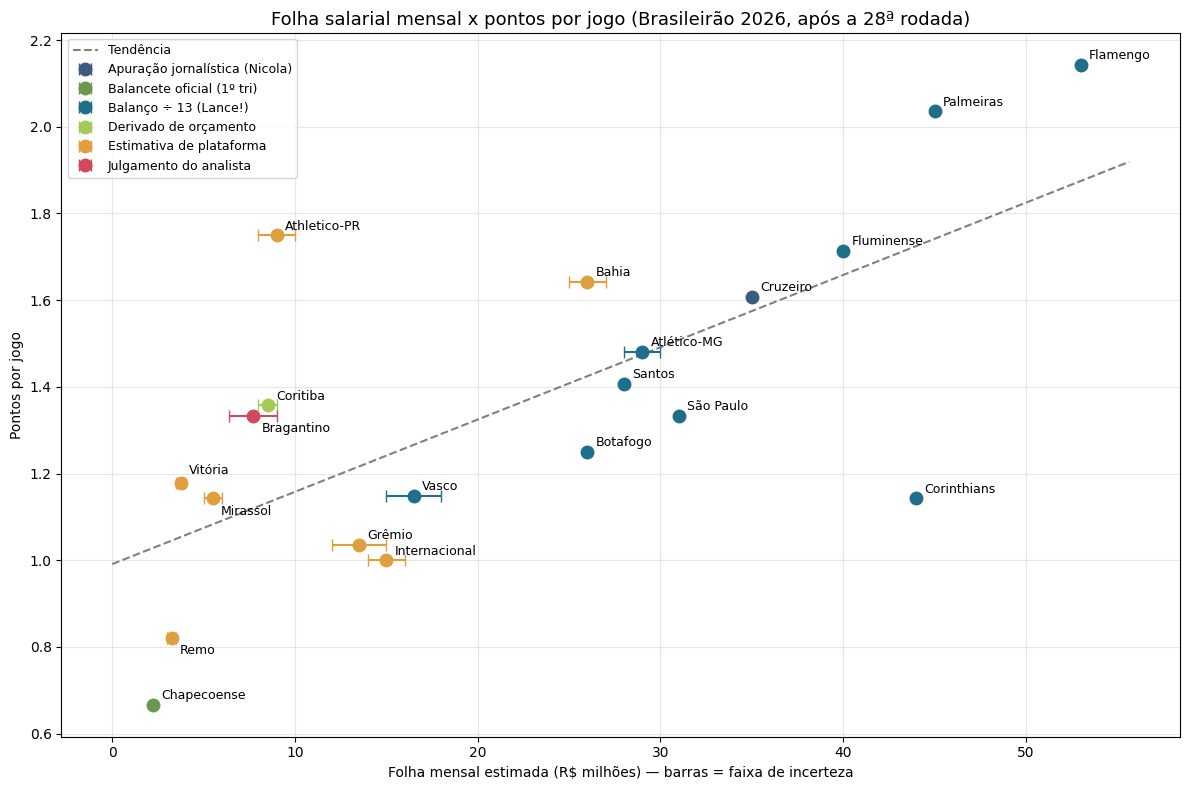

Salvo em /content/drive/MyDrive/analise_futebol/graficos/02a_folha_x_pontos.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))
for metodo, g in d.groupby('metodo_folha'):
    erro = [g['folha_mensal'] - g['folha_min'], g['folha_max'] - g['folha_mensal']]
    ax.errorbar(g['folha_mensal'], g['pontos_por_jogo'], xerr=erro, fmt='o', ms=9, capsize=4,
                color=CORES_METODO.get(metodo, 'gray'), label=metodo, zorder=3)
coef = np.polyfit(d['folha_mensal'], d['pontos_por_jogo'], 1)
xs = np.linspace(0, d['folha_mensal'].max() * 1.05, 100)
ax.plot(xs, np.polyval(coef, xs), '--', color='gray', label='Tendência')
rotular(ax, d, 'folha_mensal', 'pontos_por_jogo',
        {'Mirassol': (6, -12), 'Vitória': (6, 6), 'Bragantino': (6, -12), 'Remo': (6, -12)})
ax.set_title('Folha salarial mensal x pontos por jogo (Brasileirão 2026, após a 28ª rodada)', fontsize=13)
ax.set_xlabel('Folha mensal estimada (R$ milhões) — barras = faixa de incerteza')
ax.set_ylabel('Pontos por jogo')
ax.grid(alpha=0.3); ax.legend(loc='upper left', fontsize=9)
salvar('02a_folha_x_pontos.png')

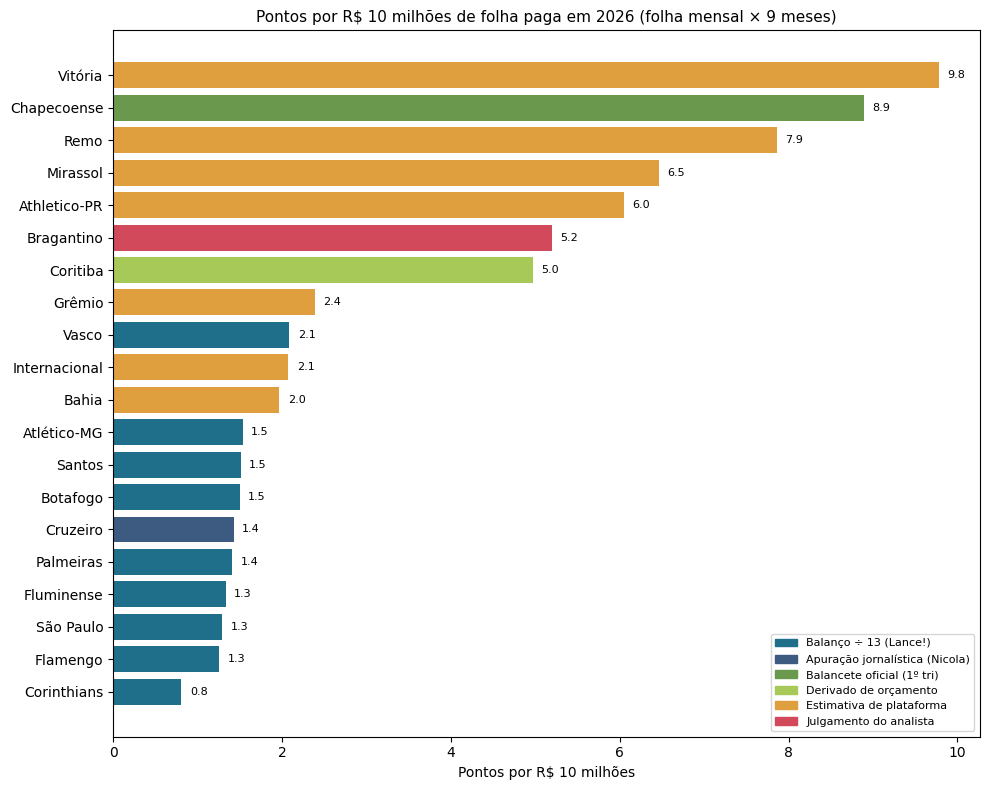

Salvo em /content/drive/MyDrive/analise_futebol/graficos/02b_pontos_por_folha.png


In [ ]:
t = d.sort_values('pontos_por_10mi_folha')
fig, ax = plt.subplots(figsize=(10, 8))
ax.barh(t['time'], t['pontos_por_10mi_folha'], color=[CORES_METODO.get(m, 'gray') for m in t['metodo_folha']])
for i, v in enumerate(t['pontos_por_10mi_folha']):
    ax.text(v + 0.1, i, f'{v:.1f}', va='center', fontsize=8)
ax.set_title(f'Pontos por R$ 10 milhões de folha paga em 2026 (folha mensal × {MESES_DECORRIDOS} meses)', fontsize=11)
ax.set_xlabel('Pontos por R$ 10 milhões')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=m) for m, c in CORES_METODO.items()], loc='lower right', fontsize=8)
salvar('02b_pontos_por_folha.png')